# **Anàlisi Horària de les Pluges**

Aquest notebook analitza a quines hores del dia és més probable que plogui, utilitzant les dades horàries de les estacions de **Vacarisses** i **Sabadell Nord (Parc Agrari)**.

## 1. Càrrega i Preparació de Dades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carregar dades horàries
df_vac = pd.read_csv('https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Vacarisses_hourly.csv')
df_sbd = pd.read_csv('https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_hourly.csv')

print(f"Vacarisses: {len(df_vac)} registres")
print(f"Sbd Nord:   {len(df_sbd)} registres")

Vacarisses: 525936 registres
Sbd Nord:   305664 registres


In [2]:
# Convertir datetime
df_vac['datetime_utc'] = pd.to_datetime(df_vac['datetime_utc'])
df_sbd['datetime_utc'] = pd.to_datetime(df_sbd['datetime_utc'])

print(f"Vacarisses: {df_vac['datetime_utc'].min()} → {df_vac['datetime_utc'].max()}")
print(f"Sbd Nord:   {df_sbd['datetime_utc'].min()} → {df_sbd['datetime_utc'].max()}")

Vacarisses: 1996-02-16 00:00:00 → 2026-04-01 23:30:00
Sbd Nord:   2008-10-24 00:00:00 → 2026-04-01 23:30:00


### Resampleig a intervals horaris

Les dades originals estan a intervals de 30 minuts. Fem resampleig a 1 hora sumant la pluja (`rain_mm`) i fent mitjana de la resta de variables.

In [3]:
def resample_hourly(df, station_name):
    df = df.copy()
    df = df.set_index('datetime_utc')
    
    # Per a la pluja: suma dels dos intervals de 30 min
    agg_dict = {'rain_mm': 'sum'}
    # Per a la resta: mitjana
    for col in df.columns:
        if col != 'rain_mm':
            agg_dict[col] = 'mean'
    
    hourly = df.resample('h').agg(agg_dict).dropna(how='all', subset=['rain_mm'])
    hourly = hourly.reset_index()
    
    # Extreure hora, any, mes
    hourly['hour'] = hourly['datetime_utc'].dt.hour
    hourly['year'] = hourly['datetime_utc'].dt.year
    hourly['month'] = hourly['datetime_utc'].dt.month
    
    print(f"{station_name}: {len(hourly)} hores després del resampleig")
    return hourly

df_vac_h = resample_hourly(df_vac, 'Vacarisses')
df_sbd_h = resample_hourly(df_sbd, 'Sbd Nord')

Vacarisses: 264072 hores després del resampleig
Sbd Nord: 152856 hores després del resampleig


## 2. Comprovació de Cobertura de Dades

Verifiquem que hi hagi prou dades per any per considerar-lo vàlid. Un any es considera **incomplet** si té menys del **70%** de les hores esperades.

In [4]:
def check_year_coverage(df, station_name, threshold=0.70):
    # Hores esperades per any (365.25 * 24 ≈ 8766)
    expected_hours_per_year = 8766
    
    coverage = df.groupby('year')['rain_mm'].count().rename('hours_present')
    coverage = coverage.to_frame()
    coverage['expected'] = expected_hours_per_year
    coverage['pct'] = coverage['hours_present'] / coverage['expected']
    coverage['status'] = coverage['pct'].apply(
        lambda x: '✓ OK' if x >= threshold else '⚠ Incomplet'
    )
    
    print(f"\n{'='*60}")
    print(f"  COBERTURA DE DADES — {station_name}")
    print(f"  (Llindar mínim: {threshold*100:.0f}% = {int(threshold*expected_hours_per_year)} hores/any)")
    print(f"{'='*60}")
    print(coverage[['hours_present', 'pct', 'status']].to_string(
        formatters={'pct': '{:.1%}'.format}
    ))
    
    valid_years = coverage[coverage['pct'] >= threshold].index.tolist()
    print(f"\n  Anys vàlids ({len(valid_years)}): {valid_years}")
    
    incomplete = coverage[coverage['pct'] < threshold]
    if len(incomplete) > 0:
        print(f"  Anys incomplets ({len(incomplete)}): {incomplete.index.tolist()}")
    
    return valid_years

valid_years_vac = check_year_coverage(df_vac_h, 'Vacarisses')
valid_years_sbd = check_year_coverage(df_sbd_h, 'Sbd Nord')


  COBERTURA DE DADES — Vacarisses
  (Llindar mínim: 70% = 6136 hores/any)
      hours_present    pct       status
year                                   
1996           7680  87.6%         ✓ OK
1997           8760  99.9%         ✓ OK
1998           8760  99.9%         ✓ OK
1999           8760  99.9%         ✓ OK
2000           8784 100.2%         ✓ OK
2001           8760  99.9%         ✓ OK
2002           8760  99.9%         ✓ OK
2003           8760  99.9%         ✓ OK
2004           8784 100.2%         ✓ OK
2005           8760  99.9%         ✓ OK
2006           8760  99.9%         ✓ OK
2007           8760  99.9%         ✓ OK
2008           8784 100.2%         ✓ OK
2009           8760  99.9%         ✓ OK
2010           8760  99.9%         ✓ OK
2011           8760  99.9%         ✓ OK
2012           8784 100.2%         ✓ OK
2013           8760  99.9%         ✓ OK
2014           8760  99.9%         ✓ OK
2015           8760  99.9%         ✓ OK
2016           8784 100.2%         ✓ OK
2017 

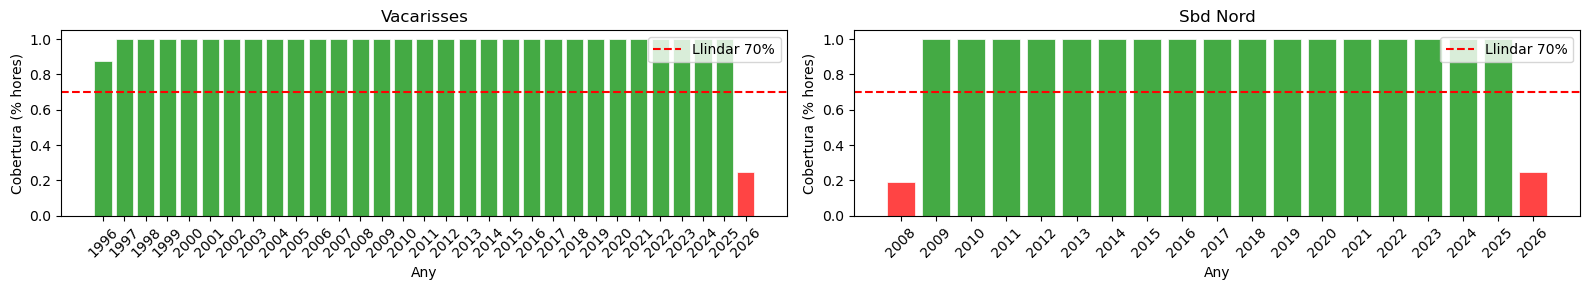

In [5]:
# Visualitzar cobertura amb heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 3))

for ax, df, name in [(axes[0], df_vac_h, 'Vacarisses'), (axes[1], df_sbd_h, 'Sbd Nord')]:
    coverage_pivot = df.groupby('year')['rain_mm'].count().to_frame('count').reset_index()
    coverage_pivot['pct'] = coverage_pivot['count'] / 8766
    
    colors = ['#ff4444' if p < 0.70 else '#44aa44' for p in coverage_pivot['pct']]
    ax.bar(coverage_pivot['year'], coverage_pivot['pct'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.70, color='red', linestyle='--', linewidth=1.5, label='Llindar 70%')
    ax.set_title(name)
    ax.set_xlabel('Any')
    ax.set_ylabel('Cobertura (% hores)')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_xticks(coverage_pivot['year'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Vacarisses — Mitjana de Pluja per Hora del Dia

In [6]:
# Filtrar només anys vàlids
df_vac_valid = df_vac_h[df_vac_h['year'].isin(valid_years_vac)]

# Mitjana de pluja per hora (0-23) a través de tots els anys vàlids
vac_hourly_avg = df_vac_valid.groupby('hour')['rain_mm'].mean()

# Trobar les hores amb més pluja
peak_hours_vac = vac_hourly_avg.nlargest(3)

print("Mitjana de pluja (mm) per hora — Vacarisses (anys vàlids):")
print(f"\nHores més plujoses:")
for h, mm in peak_hours_vac.items():
    print(f"  {h:02d}:00 → {mm:.3f} mm/h")

Mitjana de pluja (mm) per hora — Vacarisses (anys vàlids):

Hores més plujoses:
  15:00 → 0.120 mm/h
  16:00 → 0.101 mm/h
  14:00 → 0.092 mm/h


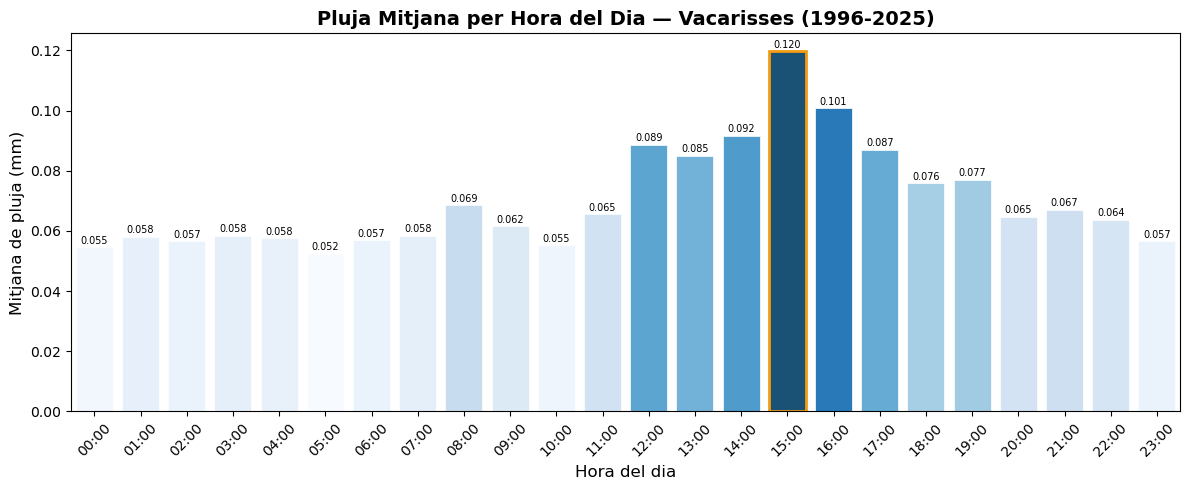

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

hours = vac_hourly_avg.index
values = vac_hourly_avg.values

# Color gradient: més fosc = més pluja
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.Blues(norm(values))

bars = ax.bar(hours, values, color=colors, edgecolor='white', linewidth=0.5)

# Destacar hora pic
peak_hour = vac_hourly_avg.idxmax()
bars[peak_hour].set_color('#1a5276')
bars[peak_hour].set_edgecolor('#f39c12')
bars[peak_hour].set_linewidth(2)

# Afegir valors a sobre
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_title(f'Pluja Mitjana per Hora del Dia — Vacarisses ({min(valid_years_vac)}-{max(valid_years_vac)})', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del dia', fontsize=12)
ax.set_ylabel('Mitjana de pluja (mm)', fontsize=12)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.show()

## 4. Sabadell Nord — Mitjana de Pluja per Hora del Dia

In [8]:
df_sbd_valid = df_sbd_h[df_sbd_h['year'].isin(valid_years_sbd)]

sbd_hourly_avg = df_sbd_valid.groupby('hour')['rain_mm'].mean()

peak_hours_sbd = sbd_hourly_avg.nlargest(3)

print("Mitjana de pluja (mm) per hora — Sbd Nord (anys vàlids):")
print(f"\nHores més plujoses:")
for h, mm in peak_hours_sbd.items():
    print(f"  {h:02d}:00 → {mm:.3f} mm/h")

Mitjana de pluja (mm) per hora — Sbd Nord (anys vàlids):

Hores més plujoses:
  15:00 → 0.104 mm/h
  14:00 → 0.096 mm/h
  16:00 → 0.091 mm/h


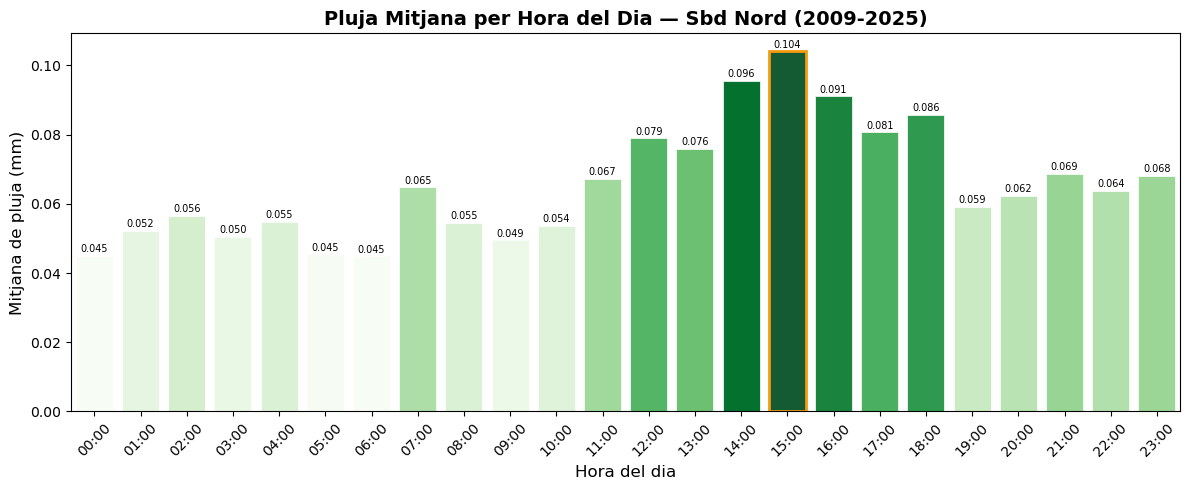

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

hours = sbd_hourly_avg.index
values = sbd_hourly_avg.values

norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.Greens(norm(values))

bars = ax.bar(hours, values, color=colors, edgecolor='white', linewidth=0.5)

peak_hour = sbd_hourly_avg.idxmax()
bars[peak_hour].set_color('#145a32')
bars[peak_hour].set_edgecolor('#f39c12')
bars[peak_hour].set_linewidth(2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_title(f'Pluja Mitjana per Hora del Dia — Sbd Nord ({min(valid_years_sbd)}-{max(valid_years_sbd)})', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del dia', fontsize=12)
ax.set_ylabel('Mitjana de pluja (mm)', fontsize=12)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.show()

## 5. Comparació entre Estacions

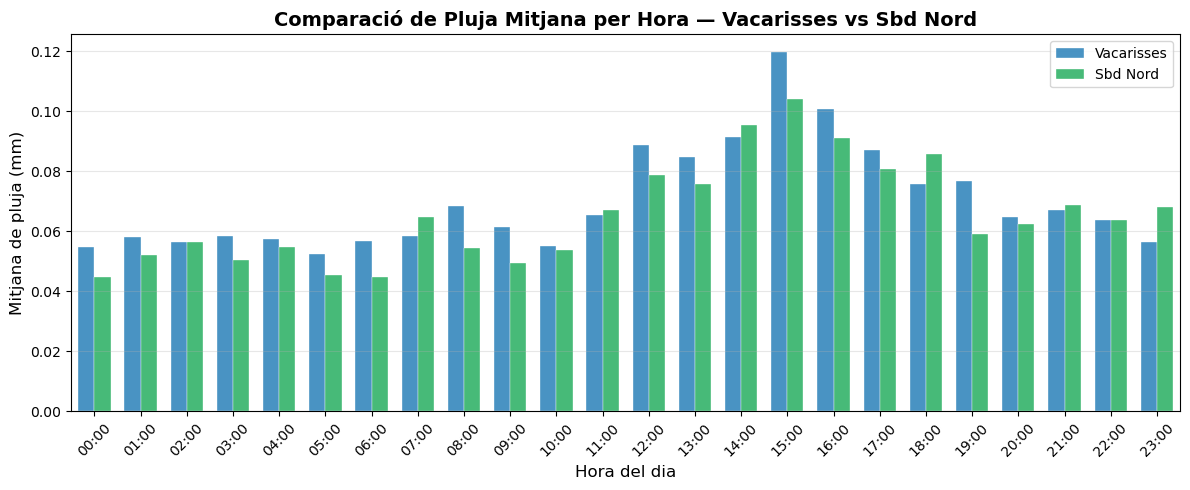

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

width = 0.35
hours = np.arange(24)

bars1 = ax.bar(hours - width/2, vac_hourly_avg.values, width, label='Vacarisses', 
               color='#2980b9', edgecolor='white', linewidth=0.3, alpha=0.85)
bars2 = ax.bar(hours + width/2, sbd_hourly_avg.values, width, label='Sbd Nord', 
               color='#27ae60', edgecolor='white', linewidth=0.3, alpha=0.85)

ax.set_title('Comparació de Pluja Mitjana per Hora — Vacarisses vs Sbd Nord', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del dia', fontsize=12)
ax.set_ylabel('Mitjana de pluja (mm)', fontsize=12)
ax.set_xticks(hours)
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.legend()
ax.set_xlim(-0.5, 23.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Resum numèric de comparació
comparison = pd.DataFrame({
    'Vacarisses': vac_hourly_avg,
    'Sbd Nord': sbd_hourly_avg,
    'Diferència': sbd_hourly_avg.values - vac_hourly_avg.values
})
comparison.index = [f'{h:02d}:00' for h in range(24)]
comparison.index.name = 'Hora'

print("Comparació numèrica (mm/h):")
print(comparison.to_string(float_format='%.4f'))

Comparació numèrica (mm/h):
       Vacarisses  Sbd Nord  Diferència
Hora                                   
00:00      0.0547    0.0449     -0.0098
01:00      0.0581    0.0522     -0.0059
02:00      0.0566    0.0565     -0.0001
03:00      0.0585    0.0505     -0.0080
04:00      0.0576    0.0547     -0.0029
05:00      0.0524    0.0454     -0.0069
06:00      0.0569    0.0448     -0.0121
07:00      0.0585    0.0647      0.0062
08:00      0.0686    0.0546     -0.0140
09:00      0.0615    0.0494     -0.0121
10:00      0.0553    0.0537     -0.0016
11:00      0.0655    0.0671      0.0017
12:00      0.0887    0.0789     -0.0097
13:00      0.0850    0.0758     -0.0092
14:00      0.0916    0.0955      0.0039
15:00      0.1197    0.1041     -0.0156
16:00      0.1008    0.0911     -0.0098
17:00      0.0870    0.0807     -0.0063
18:00      0.0759    0.0858      0.0099
19:00      0.0770    0.0591     -0.0178
20:00      0.0648    0.0623     -0.0024
21:00      0.0670    0.0687      0.0017
22:00      0

## 6. Heatmap Hora × Mes (Patrons Estacionals)

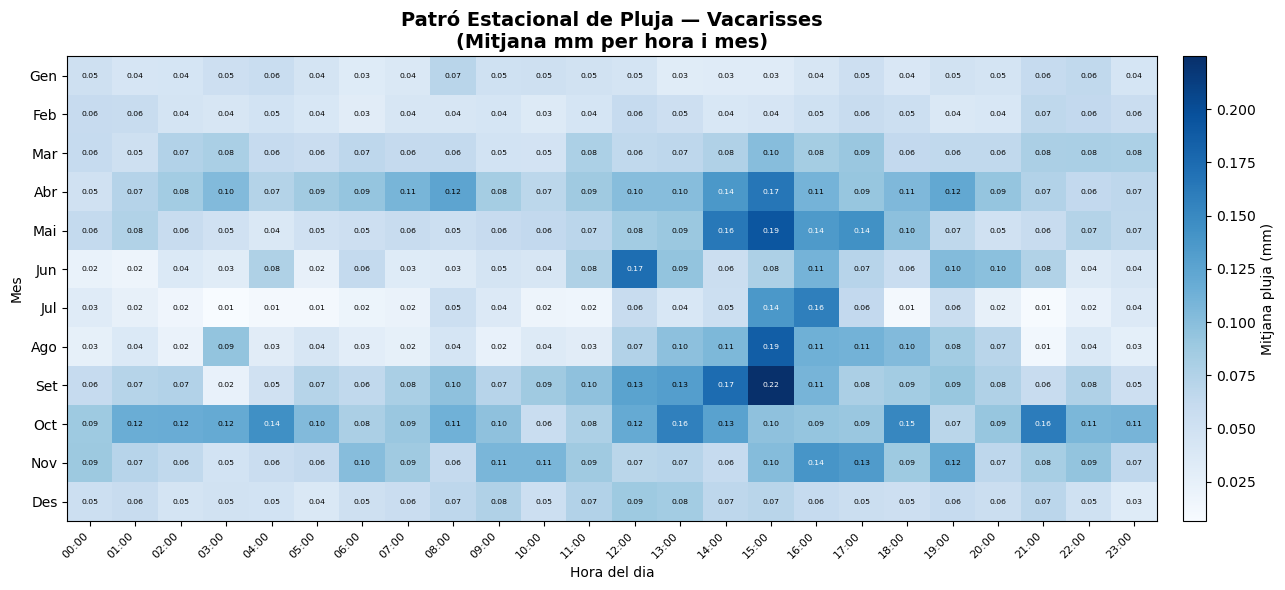

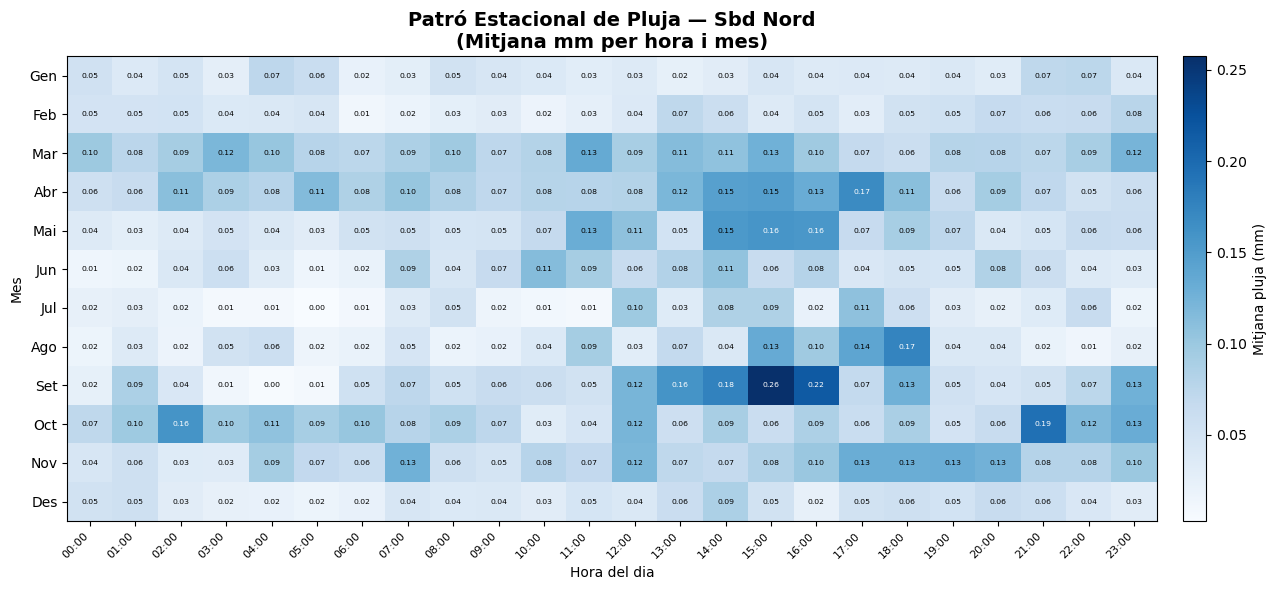

In [12]:
def create_hour_month_heatmap(df, station_name, valid_years):
    df_valid = df[df['year'].isin(valid_years)]
    
    heatmap_data = df_valid.groupby(['month', 'hour'])['rain_mm'].mean().unstack(level='hour')
    
    month_names = {
        1: 'Gen', 2: 'Feb', 3: 'Mar', 4: 'Abr',
        5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
        9: 'Set', 10: 'Oct', 11: 'Nov', 12: 'Des'
    }
    heatmap_data.index = heatmap_data.index.map(month_names)
    heatmap_data.columns = [f'{h:02d}:00' for h in heatmap_data.columns]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    im = ax.imshow(heatmap_data.values, cmap='Blues', aspect='auto')
    
    ax.set_xticks(range(24))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(12))
    ax.set_yticklabels([month_names[m] for m in range(1, 13)])
    
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('Mitjana pluja (mm)', fontsize=10)
    
    # Add text annotations with values
    for i in range(12):
        for j in range(24):
            val = heatmap_data.values[i, j]
            color = 'white' if val > heatmap_data.values.max() * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=5.5, color=color)
    
    ax.set_title(f'Patró Estacional de Pluja — {station_name}\n(Mitjana mm per hora i mes)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hora del dia')
    ax.set_ylabel('Mes')
    
    plt.tight_layout()
    plt.show()

create_hour_month_heatmap(df_vac_h, 'Vacarisses', valid_years_vac)
create_hour_month_heatmap(df_sbd_h, 'Sbd Nord', valid_years_sbd)

## 7. Resum i Conclusions

In [13]:
print("="*60)
print("  RESUM — ANÀLISI HORÀRIA DE PLUGES")
print("="*60)

print(f"\n📍 VACARISSES ({min(valid_years_vac)}-{max(valid_years_vac)}):")
print(f"   Hora més plujosa: {vac_hourly_avg.idxmax():02d}:00 ({vac_hourly_avg.max():.4f} mm/h)")
print(f"   Top 3 hores:")
for h, mm in vac_hourly_avg.nlargest(3).items():
    print(f"      {h:02d}:00 → {mm:.4f} mm/h")
print(f"   Hora menys plujosa: {vac_hourly_avg.idxmin():02d}:00 ({vac_hourly_avg.min():.4f} mm/h)")

print(f"\n📍 SBD NORD ({min(valid_years_sbd)}-{max(valid_years_sbd)}):")
print(f"   Hora més plujosa: {sbd_hourly_avg.idxmax():02d}:00 ({sbd_hourly_avg.max():.4f} mm/h)")
print(f"   Top 3 hores:")
for h, mm in sbd_hourly_avg.nlargest(3).items():
    print(f"      {h:02d}:00 → {mm:.4f} mm/h")
print(f"   Hora menys plujosa: {sbd_hourly_avg.idxmin():02d}:00 ({sbd_hourly_avg.min():.4f} mm/h)")

print("\n" + "="*60)
print("  NOTA: Les dades estan en UTC. Per convertir a hora")
print("  local catalana, suma +1h (estàndard) o +2h (estiu).")
print("="*60)

  RESUM — ANÀLISI HORÀRIA DE PLUGES

📍 VACARISSES (1996-2025):
   Hora més plujosa: 15:00 (0.1197 mm/h)
   Top 3 hores:
      15:00 → 0.1197 mm/h
      16:00 → 0.1008 mm/h
      14:00 → 0.0916 mm/h
   Hora menys plujosa: 05:00 (0.0524 mm/h)

📍 SBD NORD (2009-2025):
   Hora més plujosa: 15:00 (0.1041 mm/h)
   Top 3 hores:
      15:00 → 0.1041 mm/h
      14:00 → 0.0955 mm/h
      16:00 → 0.0911 mm/h
   Hora menys plujosa: 06:00 (0.0448 mm/h)

  NOTA: Les dades estan en UTC. Per convertir a hora
  local catalana, suma +1h (estàndard) o +2h (estiu).
